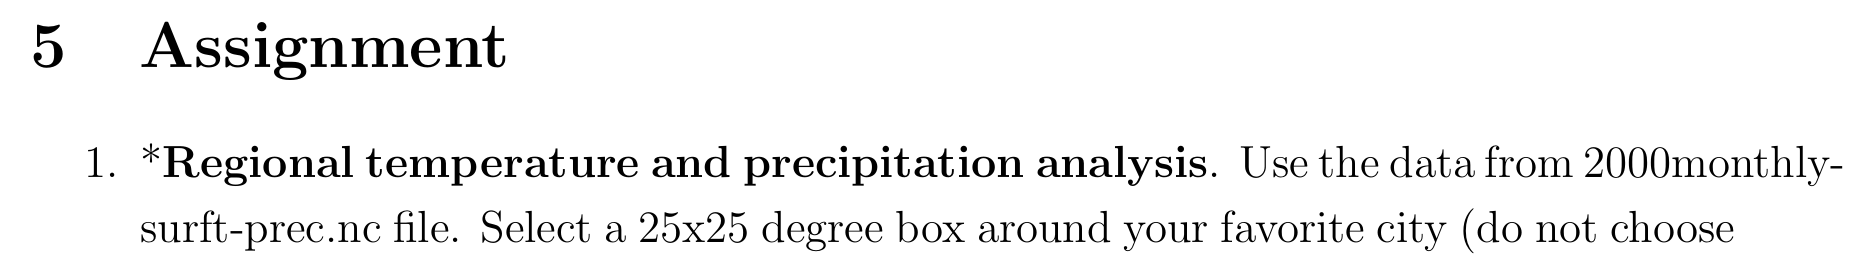
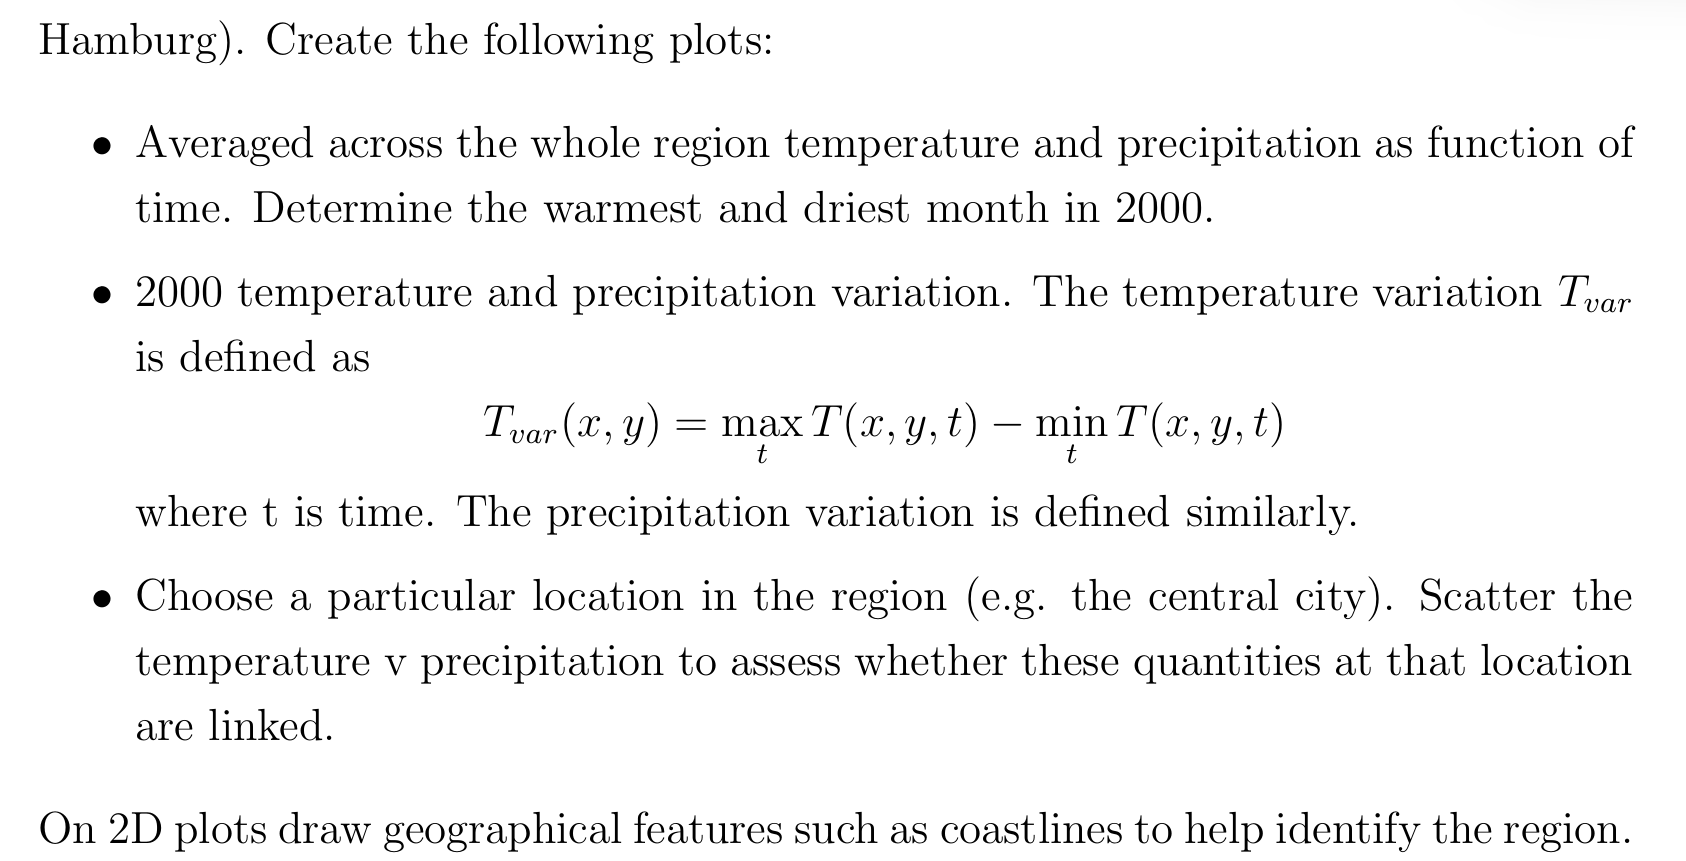

In [9]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

path = Path('2000monthly-surft-prec.nc')

ds = xr.open_dataset(path, engine='scipy')
ds

<xarray.Dataset> Size: 2MB
Dimensions:    (longitude: 144, latitude: 73, time: 12)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * time       (time) datetime64[ns] 96B 2000-01-01 2000-02-01 ... 2000-12-01
Data variables:
    lsp        (time, latitude, longitude) float64 1MB ...
    t2m        (time, latitude, longitude) float64 1MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 21:46:23 GMT by grib_to_netcdf-2.21.0: grib_to_n...

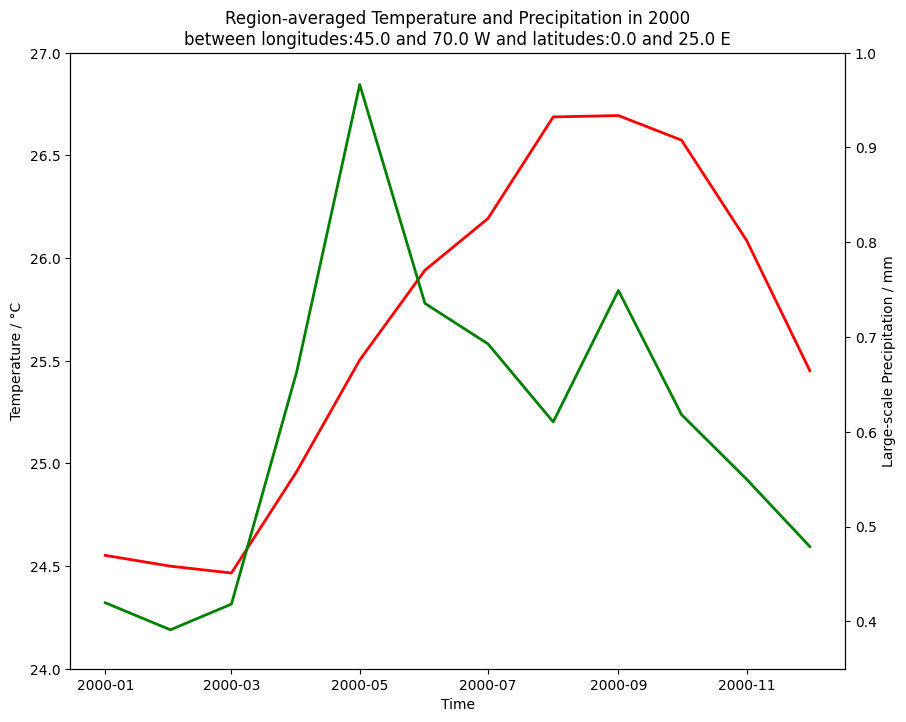

In [49]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

path = Path('2000monthly-surft-prec.nc')

ds = xr.open_dataset(path, engine='scipy')

# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon-12.5, lon+12.5)
latitudes: slice = slice(lat+12.5, lat-12.5)
lons, lats = np.meshgrid(longitudes, latitudes)

# Select mean lsp and t2m across the region.
lsp = ds['lsp'].sel(latitude=latitudes, longitude=longitudes) * 1000
lsp_mean = lsp.mean(dim=['latitude', 'longitude'])

t2m = ds['t2m'].sel(latitude=latitudes, longitude=longitudes) - 273.15
t2m_mean = t2m.mean(dim=['latitude', 'longitude'])


# Plotting.
fig, ax1 = plt.subplots(figsize=(10, 8))

ax1.plot(
    ds['time'],
    t2m_mean,
    color='red',
    linewidth=2,
    label="2 m Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature / °C")
ax1.set_title(
    (
        "Region-averaged Temperature and Precipitation in 2000\n"
        f"between longitudes:{longitudes.start.values-240} and {longitudes.stop.values-240} W and latitudes:{latitudes.stop.values} and {latitudes.start.values} E"
    )
)
ax1.set_ylim(24, 27)


ax2 = ax1.twinx()

ax2.plot(
    ds['time'],
    lsp_mean,
    color='green',
    linewidth=2,
    label="LSP Mean"
)
ax2.set_ylabel("Large-scale Precipitation / mm")
ax2.set_ylim(0.35, 1.0)


plt.show()


In [41]:
longitudes.start[0]

IndexError: too many indices

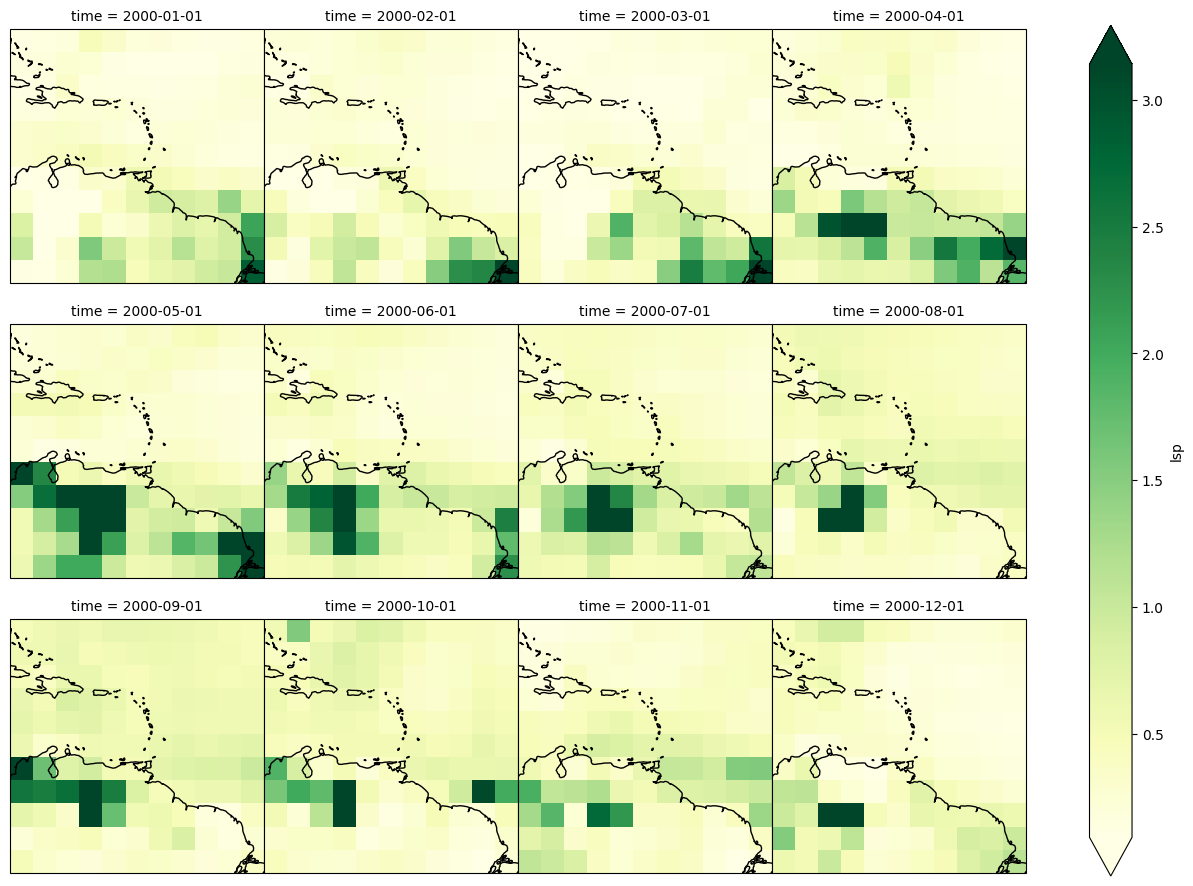

In [10]:
# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon-12.5, lon+12.5)
latitudes: slice = slice(lat+12.5, lat-12.5)
lons, lats = np.meshgrid(longitudes, latitudes)

# Select region from dataset.
rain = ds['lsp'].sel(latitude=latitudes, longitude=longitudes) * 1000

# Large-scale precipitation.
ax = rain.plot(x="longitude", y="latitude", col='time', col_wrap=4, cmap='YlGn',
               subplot_kws={'projection': ccrs.PlateCarree()},
               transform=ccrs.PlateCarree(),
               robust=True)
ax.map(lambda: plt.gca().coastlines())

plt.show()

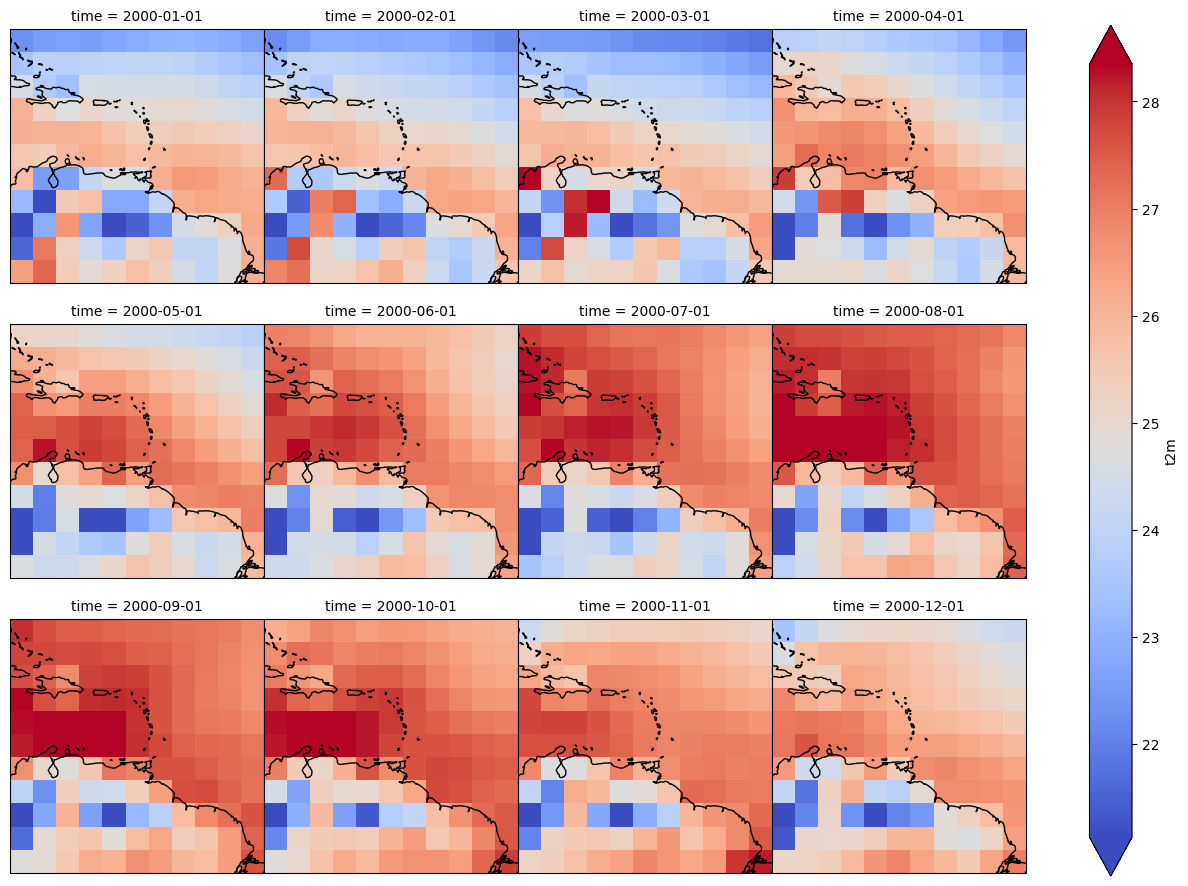

In [11]:
# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon-12.5, lon+12.5)
latitudes: slice = slice(lat+12.5, lat-12.5)

# Select region from dataset.
temps = ds['t2m'].sel(latitude=latitudes, longitude=longitudes) - 273.15

# Large-scale precipitation.
ax = temps.plot(x="longitude", y="latitude", col='time', col_wrap=4, cmap='coolwarm',
               subplot_kws={'projection': ccrs.PlateCarree()},
               transform=ccrs.PlateCarree(),
               robust=True)
ax.map(lambda: plt.gca().coastlines())

plt.show()

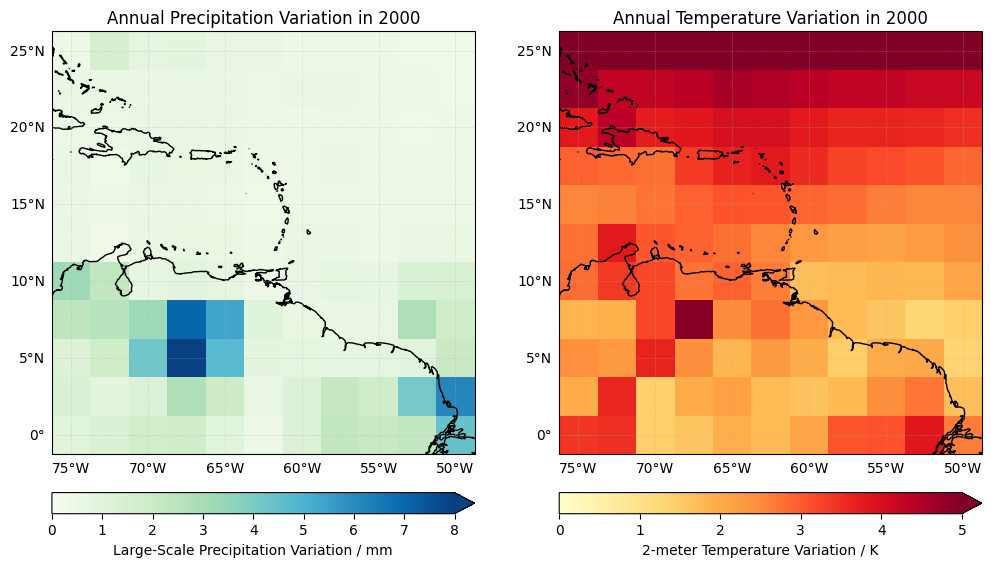

In [12]:
# Coordinates of Sauteurs, Grenada.
lon_center, lat_center = 298.3, 12.3
lon = ds['longitude'].sel(longitude=lon_center, method='nearest')
lat = ds['latitude'].sel(latitude=lat_center, method='nearest')

# Create 25 x 25 degree box around city.
longitudes: slice = slice(lon - 12.5, lon + 12.5)
latitudes: slice = slice(lat + 12.5, lat - 12.5)
# lons, lats = np.meshgrid(lon, lat)

rain = ds['lsp'].sel(latitude=latitudes, longitude=longitudes) * 1000
temps = ds['t2m'].sel(latitude=latitudes, longitude=longitudes)

rain_var = rain.max(dim='time') - rain.min(dim='time')
temps_var = temps.max(dim='time') - temps.min(dim='time')

year = rain.time.dt.year.values[0]
titles = [f"Annual Precipitation Variation in {year}", f"Annual Temperature Variation in {year}"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

pc_rain = ax1.pcolormesh(
    rain['longitude'],
    rain['latitude'],
    rain_var,
    cmap='GnBu',
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=8
)
cbar_1 = fig.colorbar(pc_rain, ax=ax1, orientation='horizontal', shrink=1, pad=0.05, extend='max')
cbar_1.set_label("Large-Scale Precipitation Variation / mm")

pc_temp = ax2.pcolormesh(
    rain['longitude'],
    rain['latitude'],
    temps_var,
    cmap='YlOrRd',
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=5
)
cbar_2 = fig.colorbar(pc_temp, ax=ax2, orientation='horizontal', shrink=1, pad=0.05, extend='max')
cbar_2.set_label("2-meter Temperature Variation / K")

for ax, title in zip([ax1, ax2], titles):
    ax.coastlines('10m')
    ax.set_title(title)

    gl = ax.gridlines(draw_labels=True, lw=0.5, ls=':', alpha=0.7)

    gl.top_labels = False
    gl.right_labels = False


plt.show()

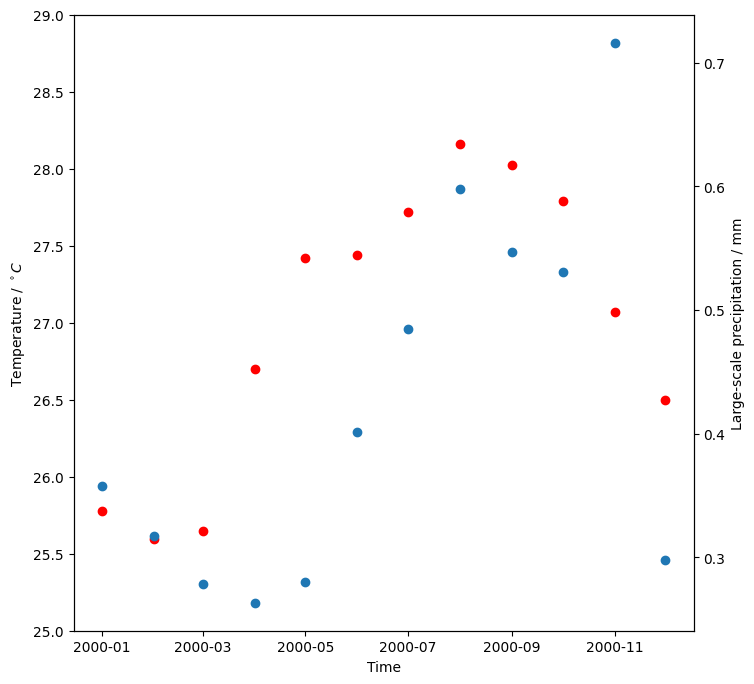

In [13]:
sauteurs_temps = ds['t2m'].sel(longitude=lon_center, latitude=lat_center, method='nearest') - 273.15

sauteurs_rain = ds['lsp'].sel(longitude=lon_center, latitude=lat_center, method='nearest') * 1_000

fig, ax1 = plt.subplots(figsize=(8, 8))
ax1.scatter(ds.time, sauteurs_temps, color='red')
ax1.set_ylabel(r"Temperature / $^\circ C$")
ax1.set_xlabel("Time")
ax1.set_ylim(25, 29)

ax2 = ax1.twinx()
ax2.scatter(ds.time, sauteurs_rain)
ax2.set_ylabel("Large-scale precipitation / mm")

plt.show()

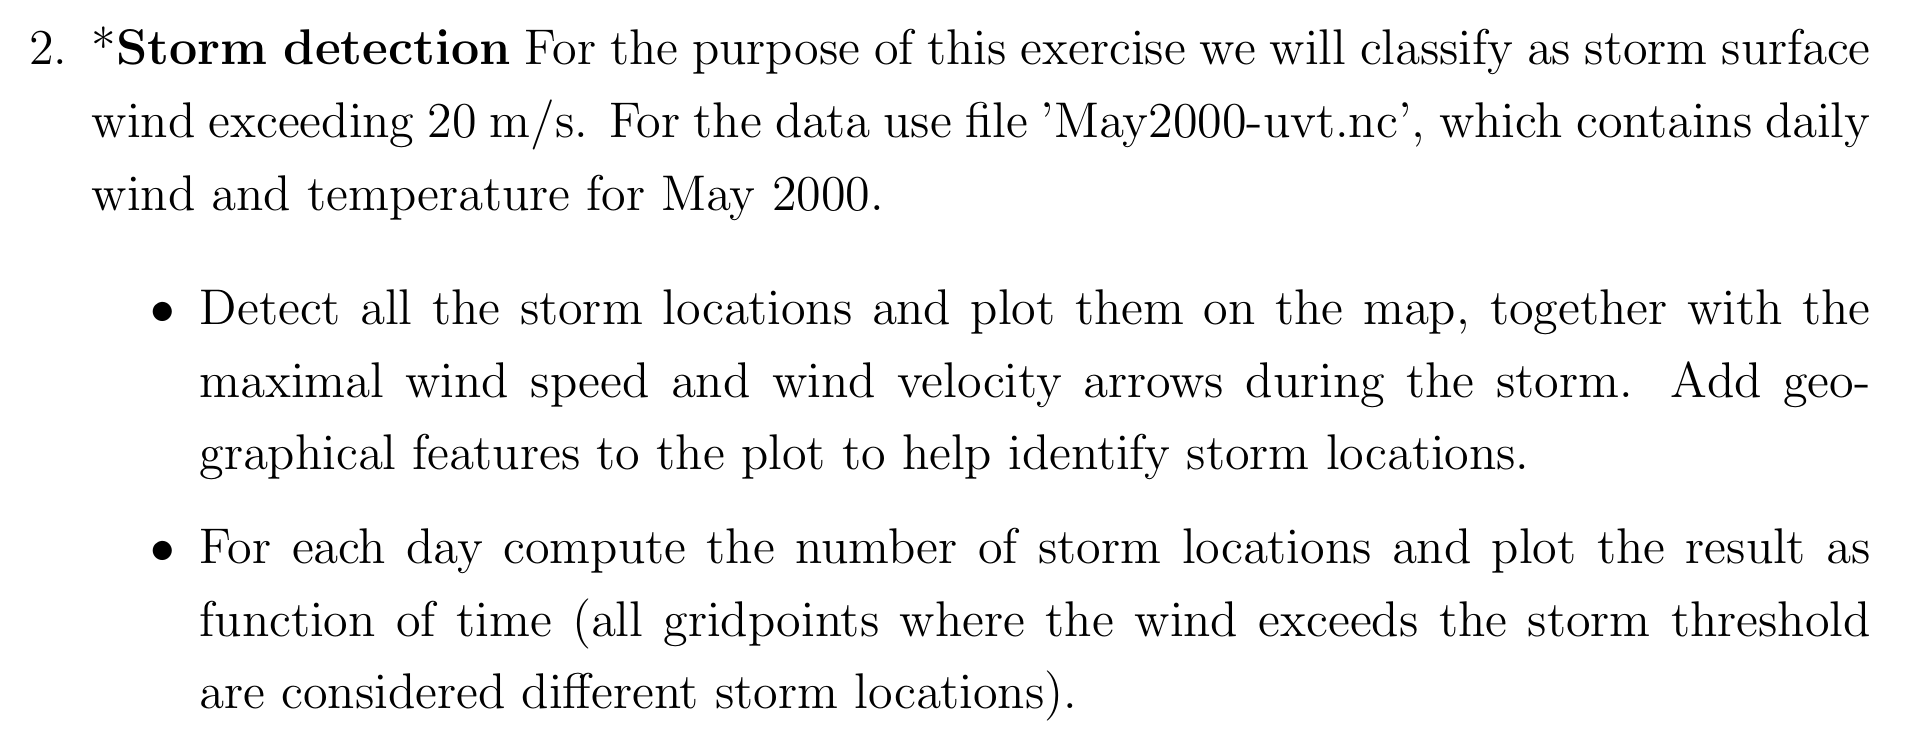

In [14]:
from pathlib import Path

import cartopy.crs as ccrs
import numpy as np
import xarray as xr

path = Path("May2000-uvt.nc")

ds = xr.open_dataset(path, engine='scipy')
ds

<xarray.Dataset> Size: 55MB
Dimensions:    (longitude: 144, latitude: 73, level: 7, time: 31)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 28B 1 10 100 250 500 775 1000
  * time       (time) datetime64[ns] 248B 2000-05-01T12:00:00 ... 2000-05-31T...
Data variables:
    t          (time, level, latitude, longitude) float64 18MB ...
    u          (time, level, latitude, longitude) float64 18MB ...
    v          (time, level, latitude, longitude) float64 18MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 22:12:40 GMT by grib_to_netcdf-2.21.0: grib_to_n...

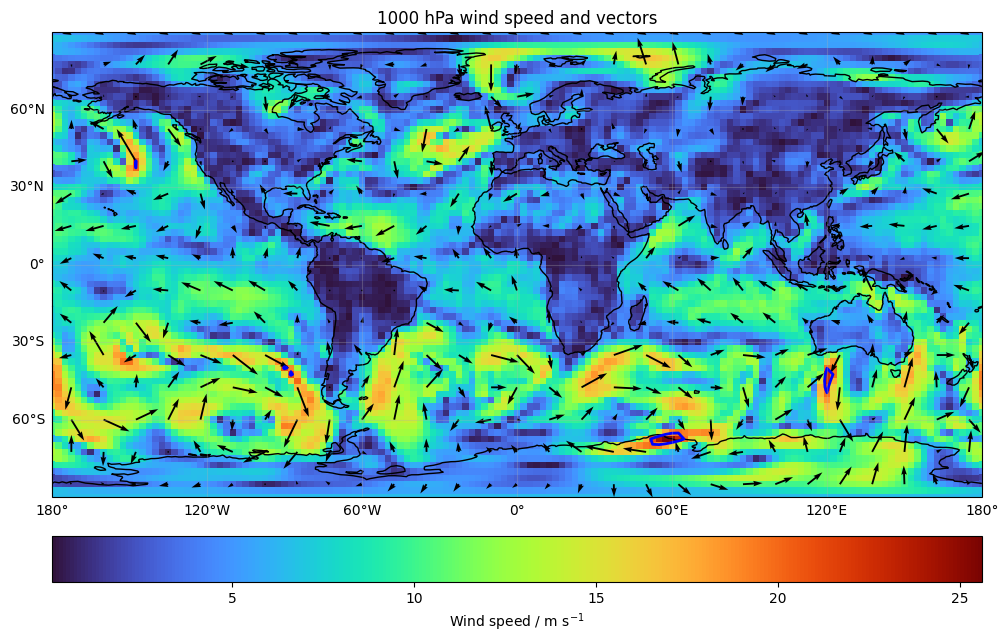

In [15]:
date = '2010-05-10'

# Select wind components.
u = ds['u'].sel(level=1000, time=date, method='nearest')
v = ds['v'].sel(level=1000, time=date, method='nearest')

# Lats and Lons.
x = ds['longitude']
y = ds['latitude']
X, Y = np.meshgrid(x, y)

# Compute wind speed.
wind_speed = np.sqrt(u**2 + v**2)

# Storms threshold.
storms = wind_speed.where(wind_speed >= 20)


# Plotting
fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw=dict(projection=ccrs.PlateCarree()))

# Wind speed.
wind_plot = ax.pcolormesh(X, Y, wind_speed, cmap='turbo')

# Wind speed > 20 m/s.
ax.contour(
    X,
    Y,
    wind_speed,
    levels=[20],
    colors='blue',
    linewidths=2,
    transform=ccrs.PlateCarree()
)

ax.contourf(
    X,
    Y,
    storms,
    levels=[20, wind_speed.max()],
    hatches=['///'],
    colors='blue',
    transform=ccrs.PlateCarree()
)

# Wind vectors
skip = 5

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    color='black',
    scale=500,
    width=0.002,
    transform=ccrs.PlateCarree()
)

ax.coastlines()

# Gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

cbar = fig.colorbar(wind_plot,
                    ax=ax,
                    label=r"Wind speed / m s$^{-1}$",
                    pad=0.05,
                    orientation='horizontal')

plt.show()

# wind_speed.plot(subplot_kws={'projection': ccrs.PlateCarree()},
#                 transform=ccrs.PlateCarree())
#
# ax = plt.gca()
# ax.quiver(X, Y, u, v, angles='uv', color='red')
# ax.coastlines()

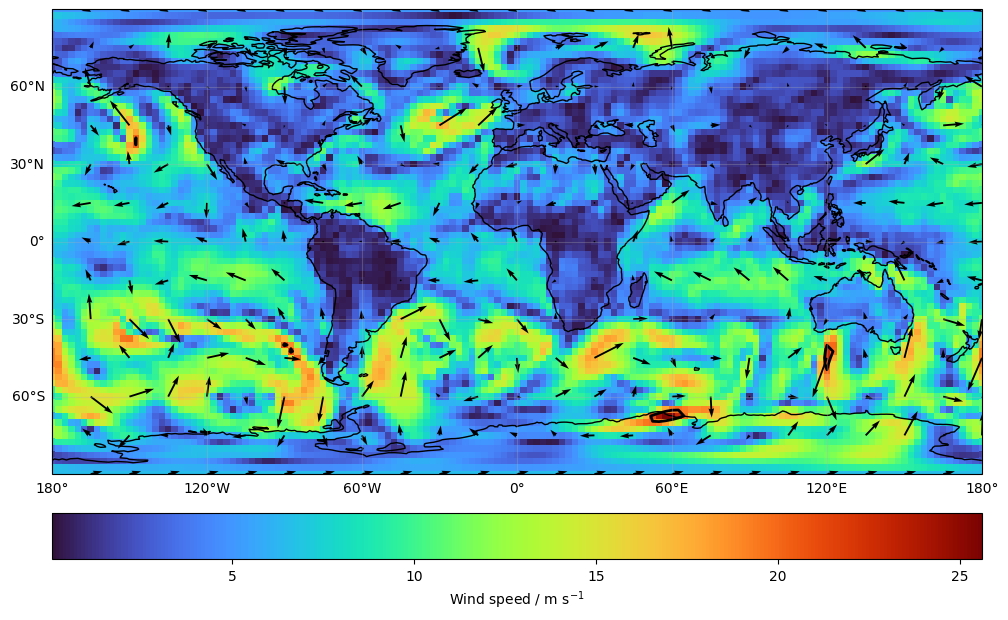

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Select date.
date = '2010-05-10'

# Select wind components.
u = ds['u'].sel(level=1000, time=date, method='nearest')
v = ds['v'].sel(level=1000, time=date, method='nearest')

# Coordinates.
lon = ds['longitude']
lat = ds['latitude']

X, Y = np.meshgrid(lon, lat)

# Wind speed.
wind_speed = np.sqrt(u**2 + v**2)

# Threshold mask.
high_winds = wind_speed.where(wind_speed >= 20)

# Figure.
fig, ax = plt.subplots(
    figsize=(12, 10),
    subplot_kw=dict(projection=ccrs.PlateCarree())
)

# Wind speed shading.
wind_plot = ax.pcolormesh(
    X,
    Y,
    wind_speed,
    cmap='turbo',
    shading='auto',
    transform=ccrs.PlateCarree()
)

# Highlight >20 m/s winds using contours.
ax.contour(
    X,
    Y,
    wind_speed,
    levels=[20],
    colors='black',
    linewidths=2,
    transform=ccrs.PlateCarree()
)

# Optional: hatch high wind regions.
ax.contourf(
    X,
    Y,
    high_winds,
    levels=[20, wind_speed.max()],
    hatches=['///'],
    colors='none',
    transform=ccrs.PlateCarree()
)

# Thin quiver vectors.
skip = 6

ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u.values[::skip, ::skip],
    v.values[::skip, ::skip],
    color='black',
    scale=500,
    width=0.002,
    transform=ccrs.PlateCarree()
)

# Coastlines.
ax.coastlines()

# Gridlines.
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Colorbar.
cbar = fig.colorbar(
    wind_plot,
    ax=ax,
    orientation='horizontal',
    pad=0.05,
    label=r'Wind speed / m s$^{-1}$'
)

plt.show()

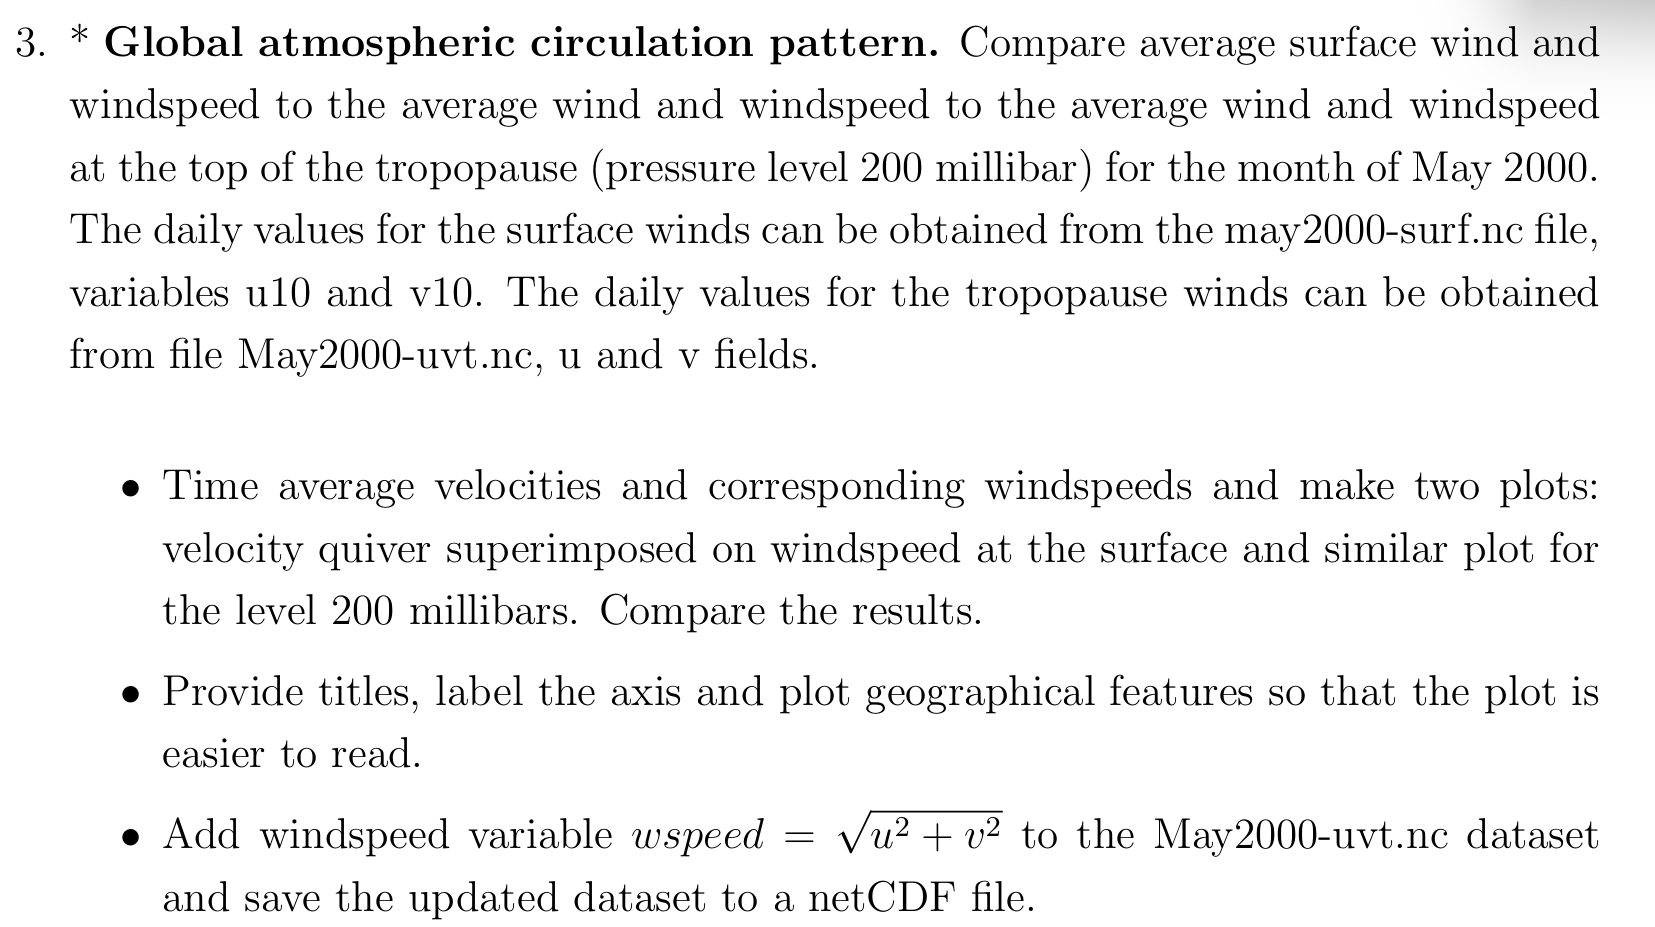
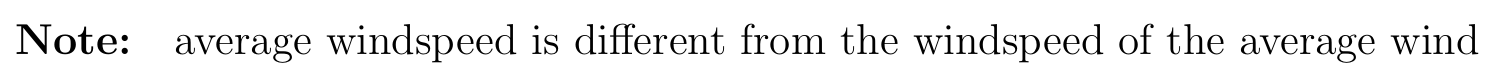
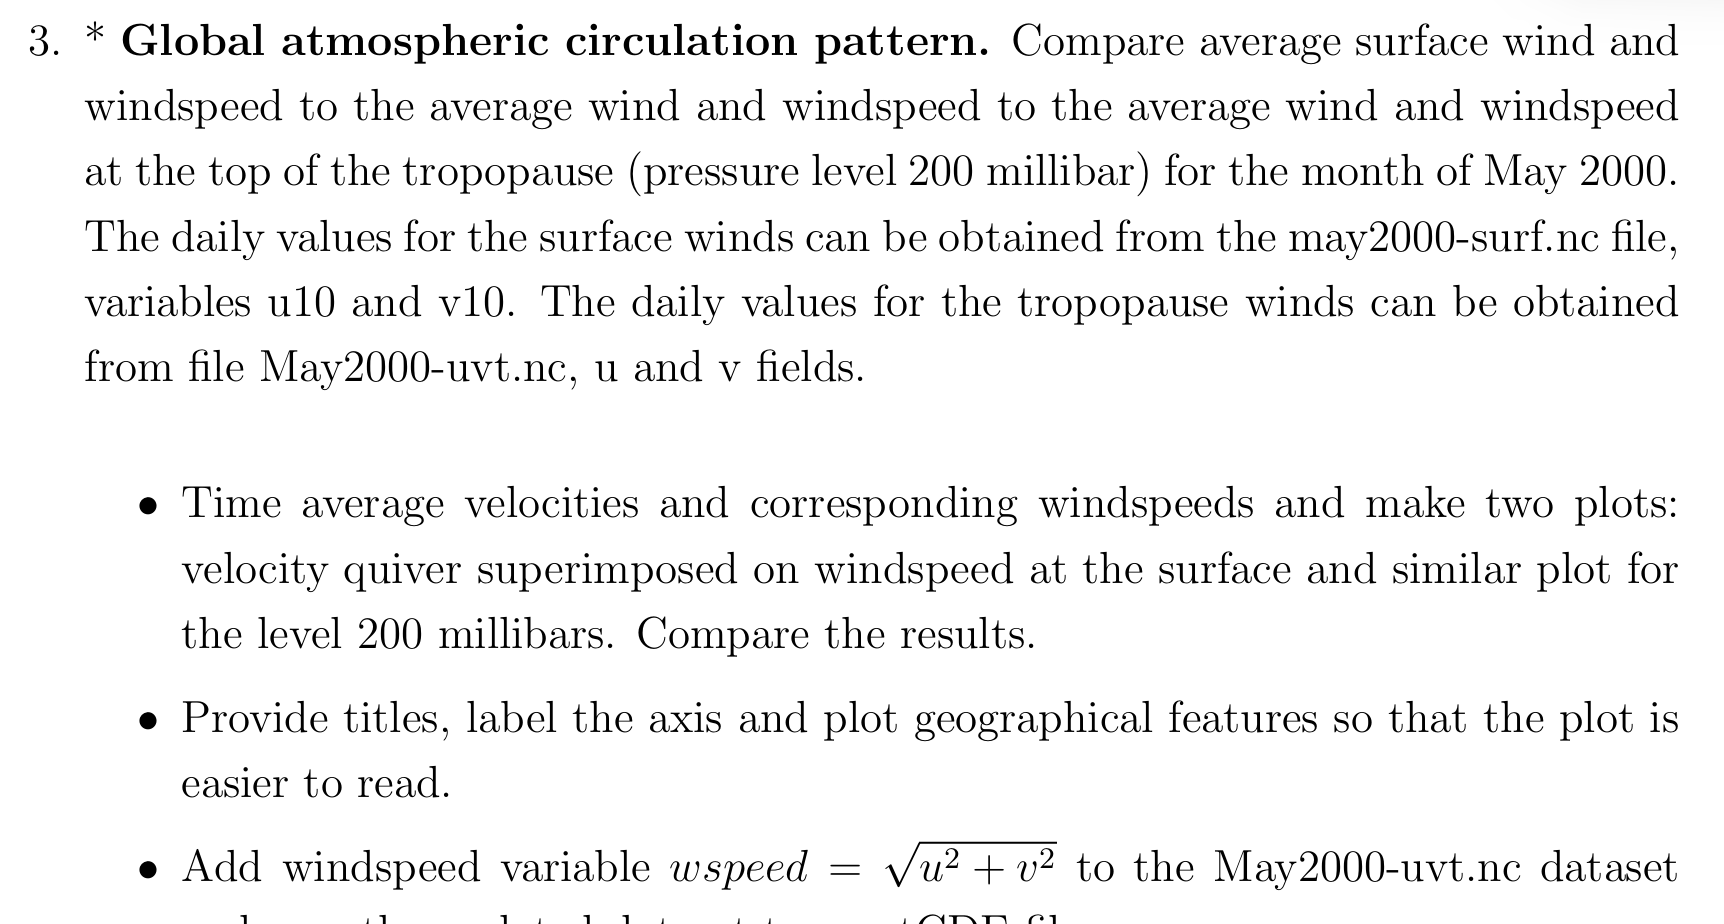
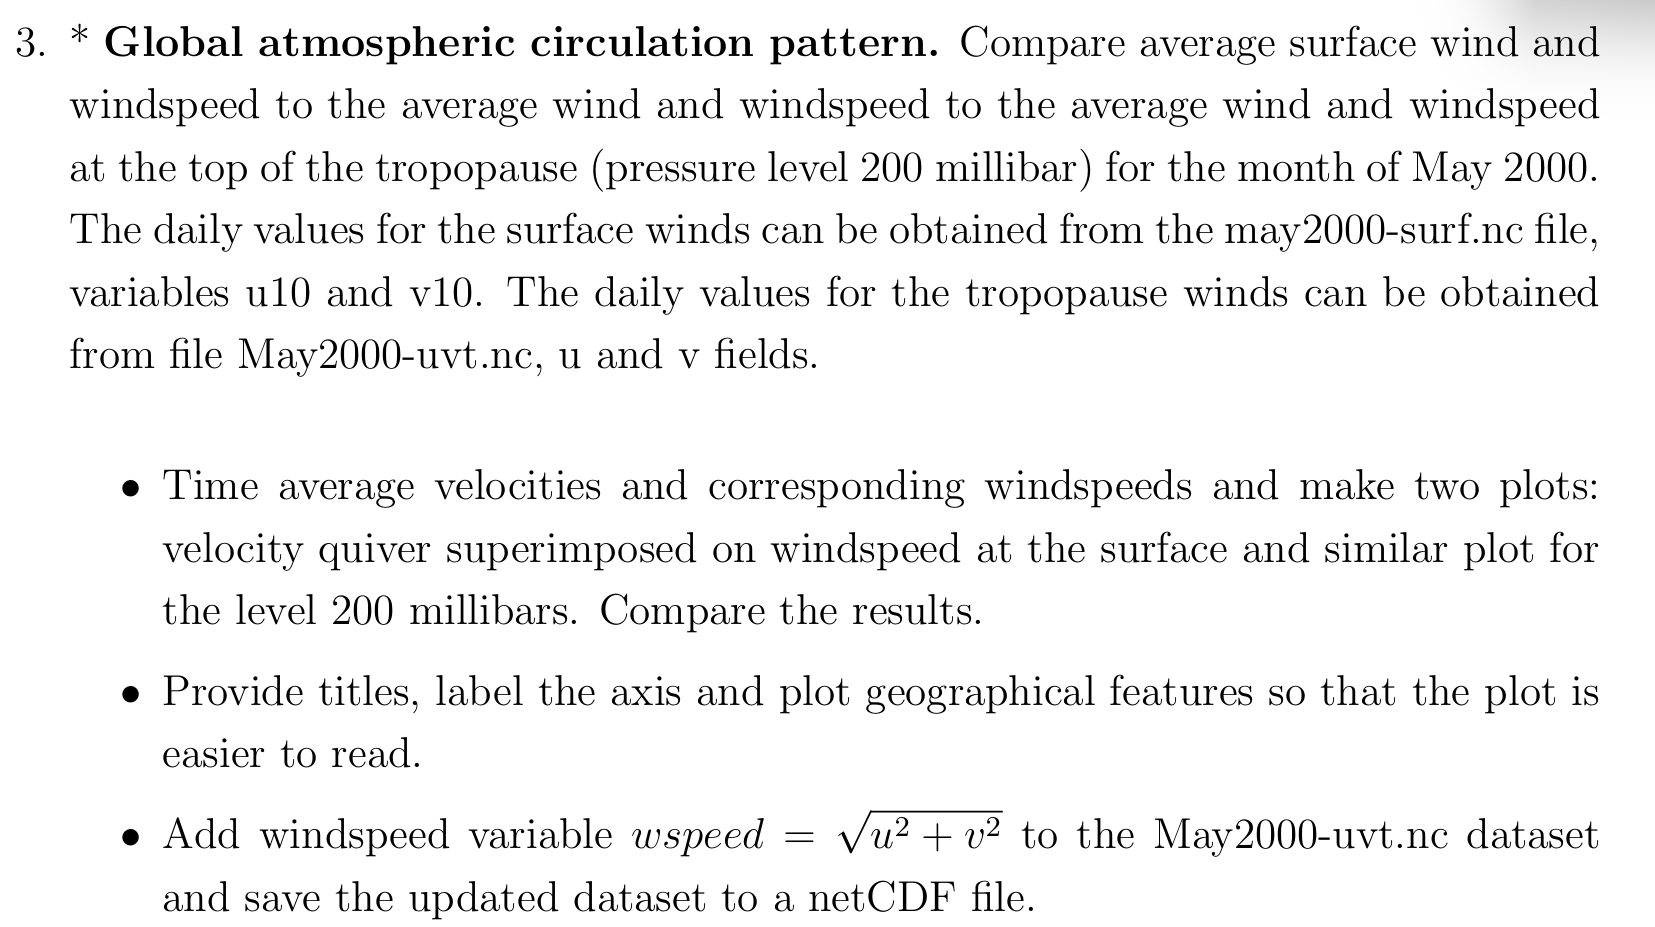

In [21]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

path1 = Path("may2000-surf.nc")
path2 = Path("May2000-uvt.nc")

ds1 = xr.open_dataset(path1, engine='scipy')
ds2 = xr.open_dataset(path2, engine='scipy')

# Load grid.
x = ds1['longitude']
y = ds1['latitude']
X, Y = np.meshgrid(x, y)

# Load surface wind data.
u10 = ds1["u10"].load().sel(time="2000-05").mean(dim='time')
v10 = ds1["v10"].load().sel(time="2000-05").mean(dim='time')
sfc_wind_speed = np.sqrt(u10 ** 2 + v10 ** 2)

# Load upper-air wind data.
u = ds2["u"].load().sel(time="2000-05")
v = ds2["v"].load().sel(time="2000-05")

# Load tropopause wind data
u250 = u.sel(level=250)
v250 = v.sel(level=250)

<xarray.DataArray 'u' (time: 31, latitude: 73, longitude: 144)> Size: 3MB
array([[[ 7.94268384e-01,  7.94268384e-01,  7.94268384e-01, ...,
          7.94268384e-01,  7.94268384e-01,  7.94268384e-01],
        [ 1.77286530e+01,  1.80866562e+01,  1.83808294e+01, ...,
          1.63216171e+01,  1.68433582e+01,  1.73151454e+01],
        [ 2.27268219e+01,  2.32957417e+01,  2.37703041e+01, ...,
          2.05815778e+01,  2.13586391e+01,  2.20774207e+01],
        ...,
        [-4.01241043e+00, -3.67938419e+00, -3.38243579e+00, ...,
         -5.21685536e+00, -4.78669646e+00, -4.38428974e+00],
        [-9.15766594e+00, -9.54619656e+00, -9.91252543e+00, ...,
         -7.86441401e+00, -8.31954988e+00, -8.74970878e+00],
        [-1.49190200e+01, -1.49190200e+01, -1.49190200e+01, ...,
         -1.49190200e+01, -1.49190200e+01, -1.49190200e+01]],

       [[ 4.69067546e+00,  4.69067546e+00,  4.69067546e+00, ...,
          4.69067546e+00,  4.69067546e+00,  4.69067546e+00],
        [ 6.80539213e+00,  7.14396881e+00,  7.46589418e+00, ...,
          5.68697898e+00,  6.07273438e+00,  6.44461369e+00],
        [ 1.26888558e+01,  1.29913546e+01,  1.32550004e+01, ...,
          1.15926444e+01,  1.19895007e+01,  1.23530543e+01],
...
        [ 7.76006736e+00,  8.02093792e+00,  8.29013414e+00, ...,
          7.15784490e+00,  7.31048193e+00,  7.51862334e+00],
        [ 6.10326179e+00,  5.94507432e+00,  5.82018948e+00, ...,
          6.79706647e+00,  6.52787025e+00,  6.29752710e+00],
        [ 4.27716787e+00,  4.27716787e+00,  4.27716787e+00, ...,
          4.27716787e+00,  4.27716787e+00,  4.27716787e+00]],

       [[-9.66830618e+00, -9.66830618e+00, -9.66830618e+00, ...,
         -9.66830618e+00, -9.66830618e+00, -9.66830618e+00],
        [ 5.03480258e+00,  5.43998452e+00,  5.85626732e+00, ...,
          3.84978419e+00,  4.23831481e+00,  4.63239587e+00],
        [-6.26643599e-01, -5.07309194e-01, -3.24144759e-01, ...,
         -6.98799285e-01, -7.09900160e-01, -6.90473629e-01],
        ...,
        [ 1.10487015e+01,  1.01328794e+01,  9.25035982e+00, ...,
          1.38544477e+01,  1.29247494e+01,  1.19839503e+01],
        [ 1.25001409e+01,  1.19062441e+01,  1.13262234e+01, ...,
          1.42929322e+01,  1.36990354e+01,  1.30968130e+01],
        [ 4.15228303e+00,  4.15228303e+00,  4.15228303e+00, ...,
          4.15228303e+00,  4.15228303e+00,  4.15228303e+00]]])
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
    level      int32 4B 250
  * time       (time) datetime64[ns] 248B 2000-05-01T12:00:00 ... 2000-05-31T...
Attributes:
    units:          m s**-1
    long_name:      U component of wind
    standard_name:  eastward_wind

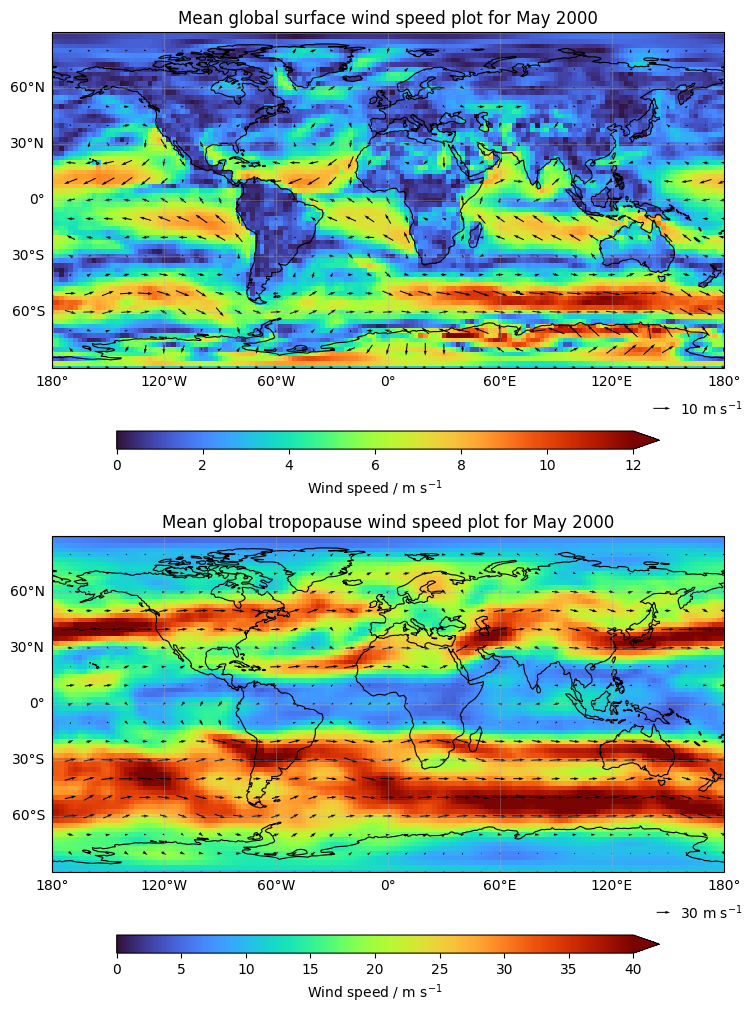

In [23]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

path1 = Path("may2000-surf.nc")
path2 = Path("May2000-uvt.nc")

ds1 = xr.open_dataset(path1, engine='scipy')
ds2 = xr.open_dataset(path2, engine='scipy')

# Load grid.
x = ds1['longitude']
y = ds1['latitude']
X, Y = np.meshgrid(x, y)

# Load surface wind data.
u10 = ds1["u10"].load().sel(time="2000-05").mean(dim='time')
v10 = ds1["v10"].load().sel(time="2000-05").mean(dim='time')
sfc_wind_speed = np.sqrt(u10**2 + v10**2)

# Load upper-air wind data.
u = ds2["u"].load().sel(time="2000-05")
v = ds2["v"].load().sel(time="2000-05")

# Load tropopause wind data
u250 = u.sel(level=250)
v250 = v.sel(level=250)
u250_mean = u250.mean(dim='time')
v250_mean = v250.mean(dim='time')

trop_wind_speed = np.sqrt(u250**2 + v250**2)
mean_trop_wind_speed = trop_wind_speed.mean(dim='time')

# Level wind speed.
wspeed = np.sqrt(u**2 + v**2)

# Assign level wind speed
ds2["wspeed"] = wspeed
ds2["wspeed"].attrs = {
    "units": "m s**-1",
    "long_name": "Wind Speed at given level",
    "standard_name": "Wind speed"
}

# Plotting.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), subplot_kw=dict(projection=ccrs.PlateCarree()))

for ax in [ax1, ax2]:
    ax.coastlines(linewidth=0.8)

    gl = ax.gridlines(draw_labels=True, alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

# Surface plot.
sfc_wind_plot = ax1.pcolormesh(
    X,
    Y,
    sfc_wind_speed,
    transform=ccrs.PlateCarree(),
    cmap='turbo',
    vmin=0,
    vmax=12,
    shading='auto'
)

fig.colorbar(sfc_wind_plot, ax=ax1, label=r"Wind speed / m s$^{-1}$", extend='max',  orientation='horizontal', shrink=0.7, fraction=0.05, aspect=30)

skip = 4

q = ax1.quiver(
    X[::skip,::skip],
    Y[::skip,::skip],
    u10[::skip,::skip],
    v10[::skip,::skip],
    transform=ccrs.PlateCarree(),

    scale=400,      # controls arrow length.
    width=0.0015,
    pivot='middle'
)
ax1.quiverkey(
    q,
    X=0.92,
    Y=-0.12,
    U=10,
    label=r'10 m s$^{-1}$',
    labelpos='E',
    coordinates='axes'
)

ax1.set_title("Mean global surface wind speed plot for May 2000")


# Tropopause plot.
trop_wind_plot = ax2.pcolormesh(
    X,
    Y,
    mean_trop_wind_speed,
    transform=ccrs.PlateCarree(),
    cmap='turbo',
    vmin=0,
    vmax=40,
    shading='auto'
)

fig.colorbar(trop_wind_plot, ax=ax2, label=r"Wind speed / m s$^{-1}$", extend='max',  orientation='horizontal', shrink=0.7, fraction=0.05, aspect=30)

skip = 4

q = ax2.quiver(
    X[::skip,::skip],
    Y[::skip,::skip],
    u250_mean[::skip,::skip],
    v250_mean[::skip,::skip],
    transform=ccrs.PlateCarree(),

    scale=1500,      # controls arrow length.
    width=0.0015,
    pivot='middle'
)
ax2.quiverkey(
    q,
    X=0.92,
    Y=-0.12,
    U=30,
    label=r'30 m s$^{-1}$',
    labelpos='E',
    coordinates='axes'
)
ax2.set_title("Mean global tropopause wind speed plot for May 2000")


plt.show()

In [24]:
ds2

<xarray.Dataset> Size: 73MB
Dimensions:    (longitude: 144, latitude: 73, level: 7, time: 31)
Coordinates:
  * longitude  (longitude) float32 576B 0.0 2.5 5.0 7.5 ... 352.5 355.0 357.5
  * latitude   (latitude) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * level      (level) int32 28B 1 10 100 250 500 775 1000
  * time       (time) datetime64[ns] 248B 2000-05-01T12:00:00 ... 2000-05-31T...
Data variables:
    t          (time, level, latitude, longitude) float64 18MB ...
    u          (time, level, latitude, longitude) float64 18MB 0.08659 ... 6.298
    v          (time, level, latitude, longitude) float64 18MB -3.743 ... 1.53
    wspeed     (time, level, latitude, longitude) float64 18MB 3.744 ... 6.481
Attributes:
    Conventions:  CF-1.6
    history:      2021-05-02 22:12:40 GMT by grib_to_netcdf-2.21.0: grib_to_n...

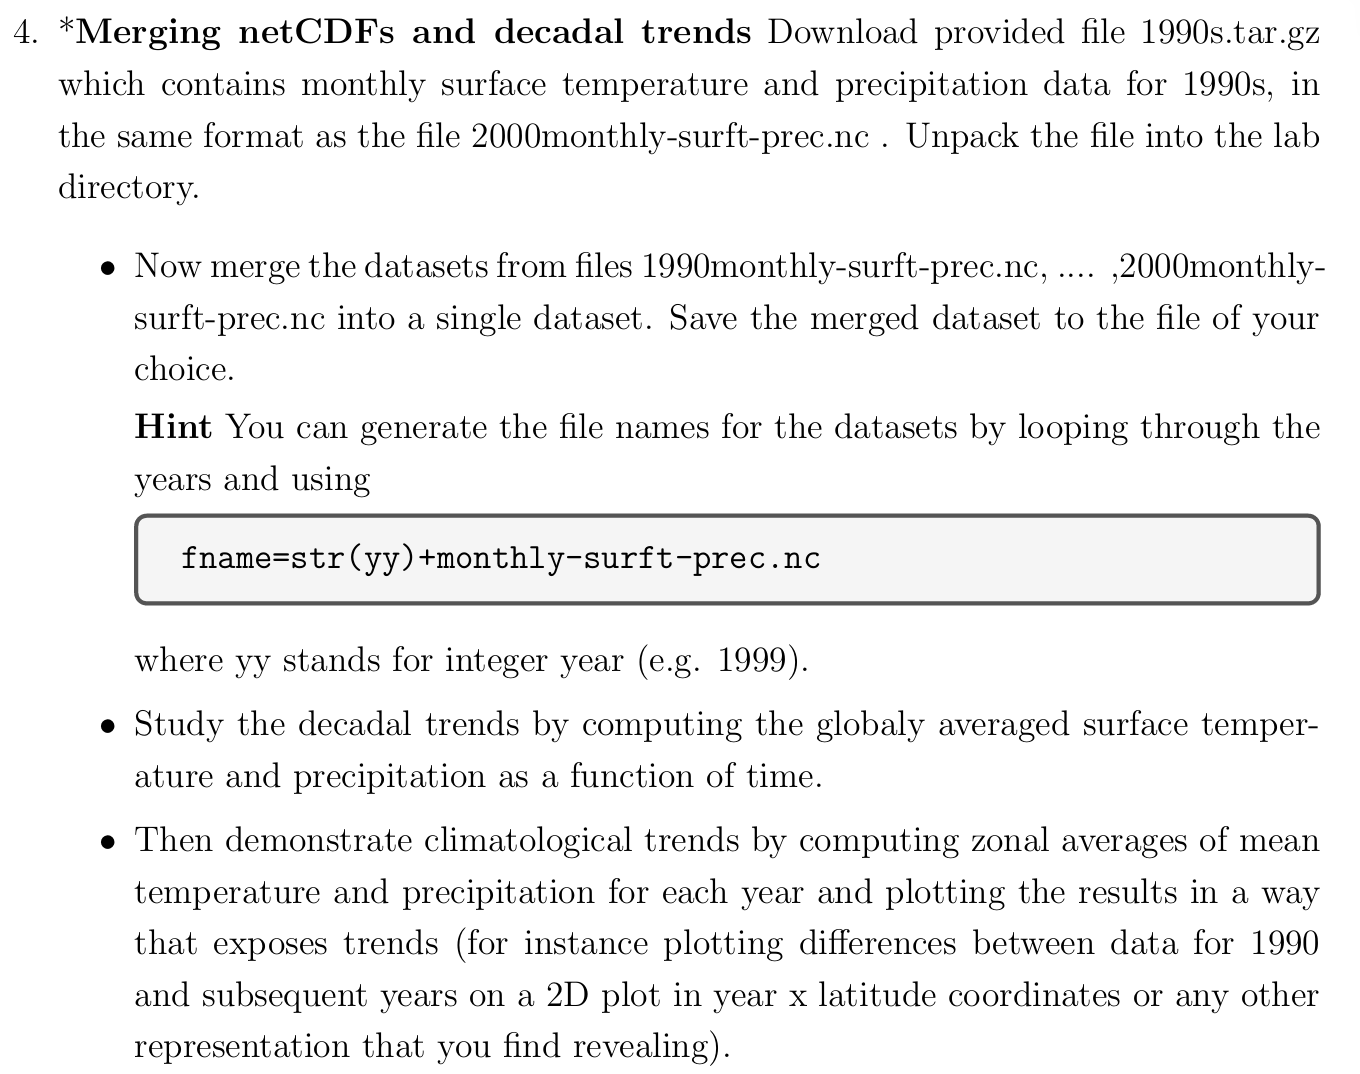

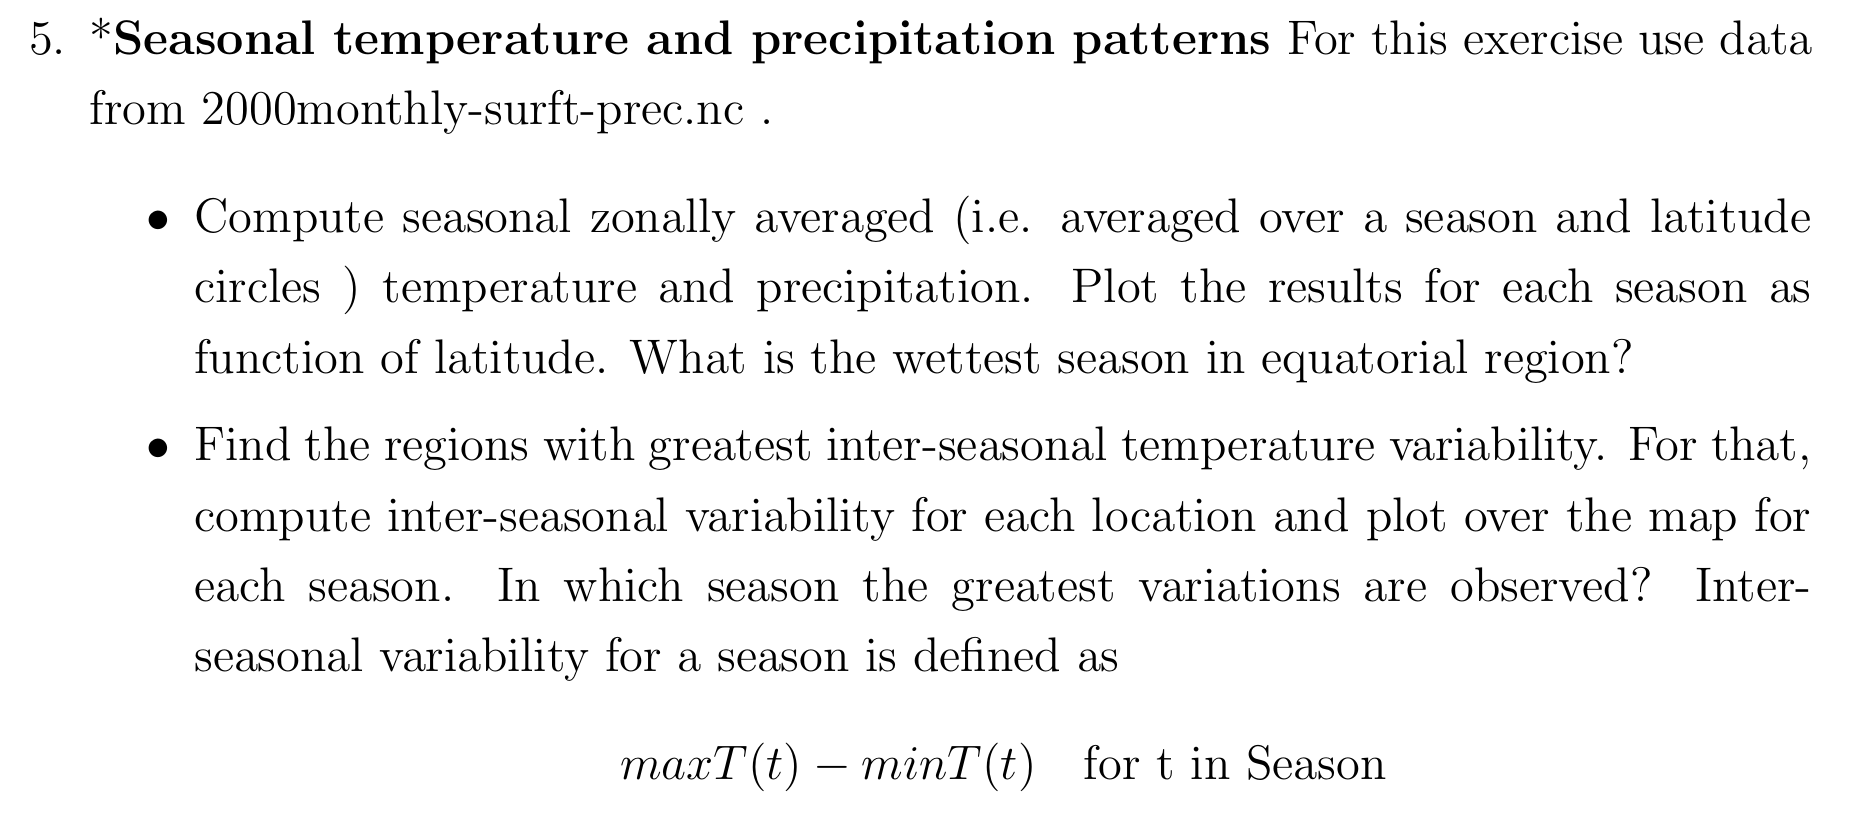

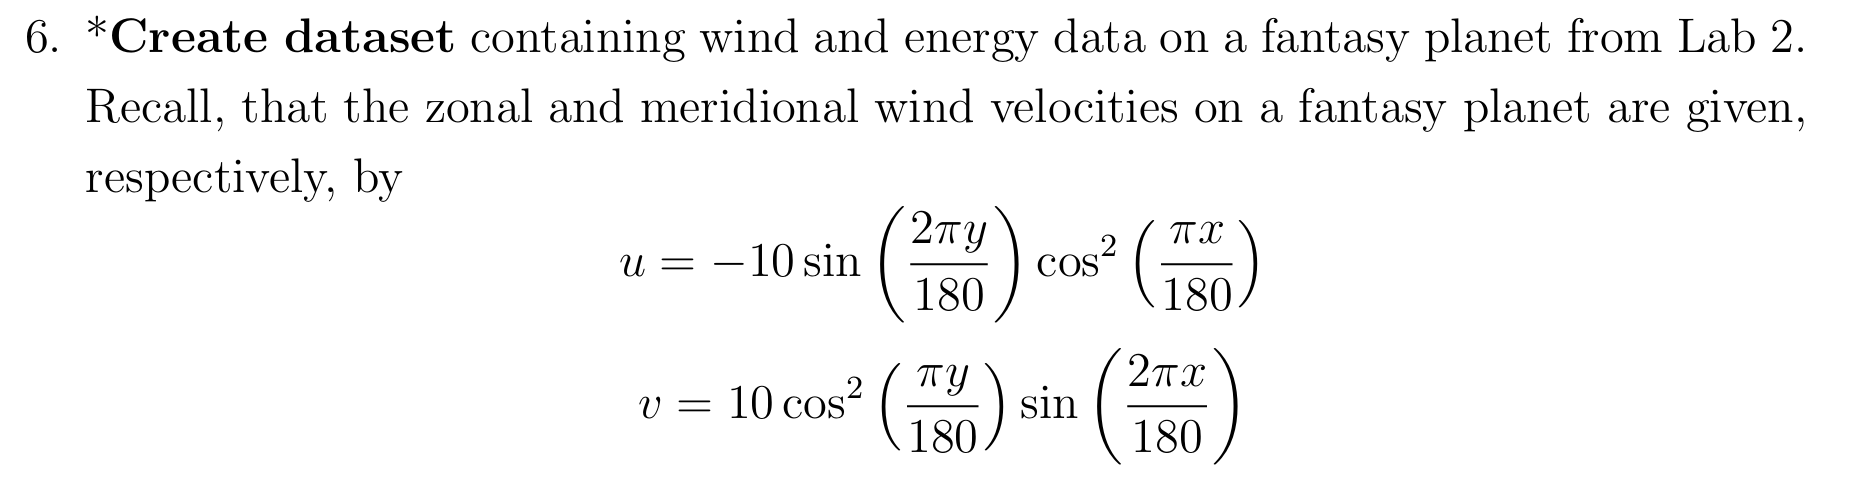
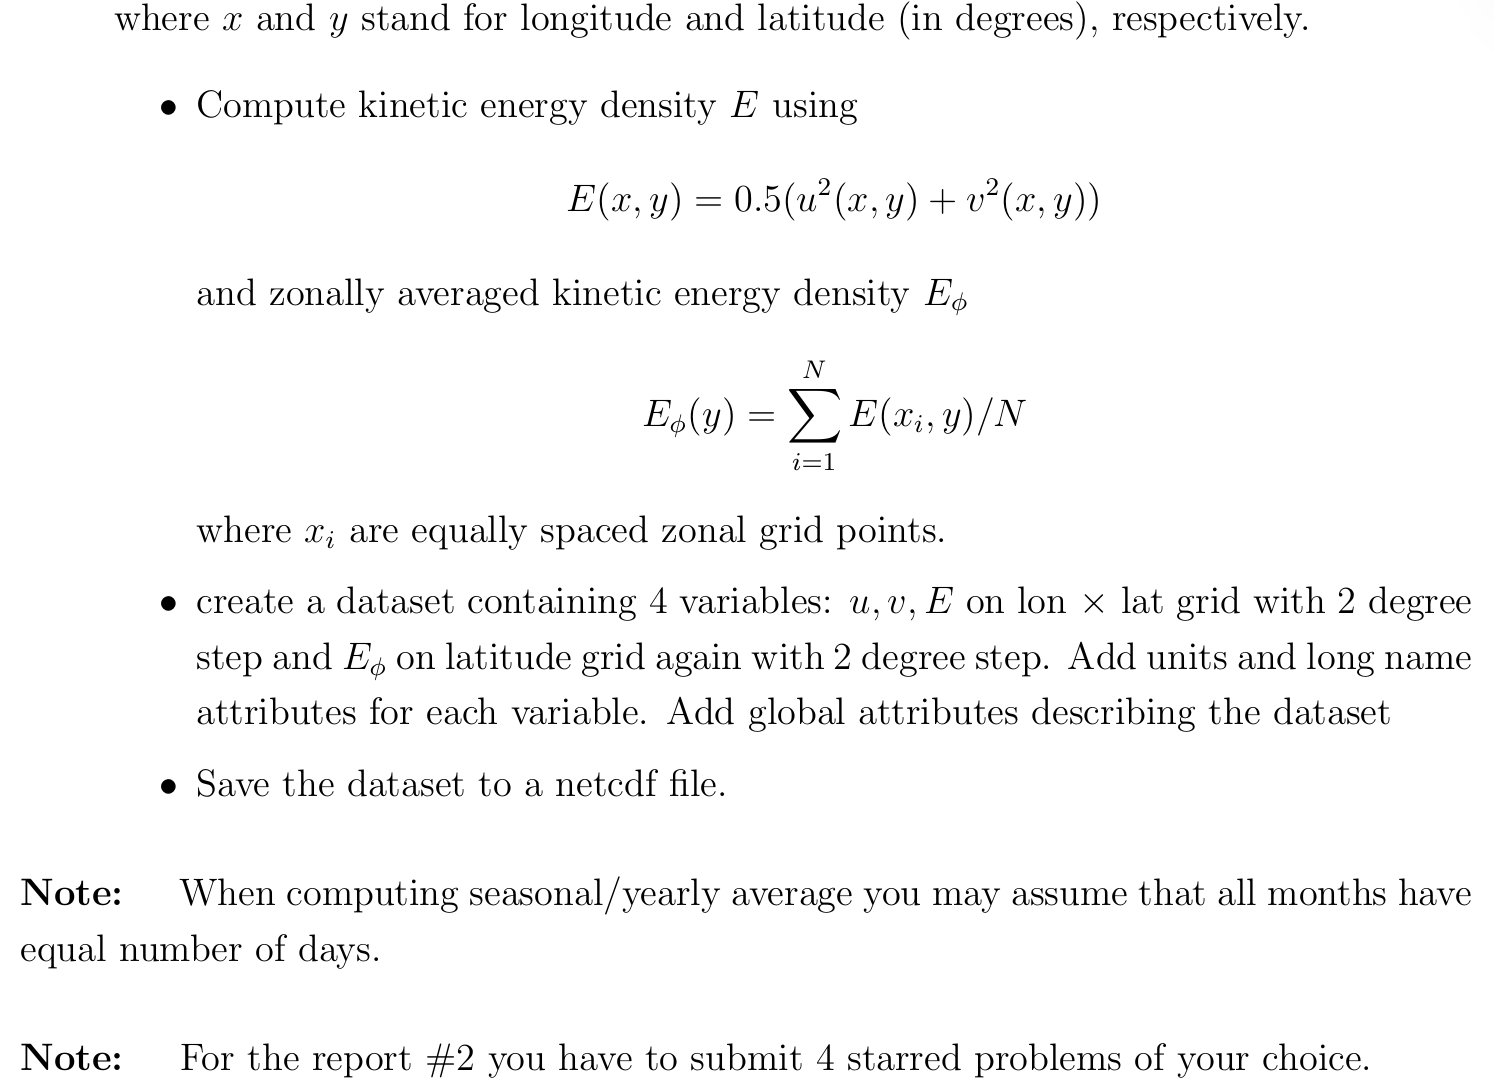